**NP PREDICTOR (MULTICLASS CLASSIFICATION)**

NP Predictor is a Machine Learning tool aimed at predicting in vitro radioenhancement of metallic nanoparticles.

**DEF AND SER PREDICTOR - MULTICLASS CLASSIFICATION TASK**

This part of NP Predictor aims as providing direct predictions of evaluation metrics DEF and SER classes.

DEF
Class 0: weak radioenhancement (DEF < 1.10) ; Class 1: average radioenhancement (1.10 < DEF < 1.25) ; Class 2: good radioenhancement (1.25 < DEF < 1.40) ; Class 3: promising radioenhancement (DEF > 1.40).

SER
Class 0: weak radioenhancement (SER < 10%) ; Class 1: average radioenhancement (10% < SER < 25%) ; Class 2: good radioenhancement (25% < SER < 40%) ; Class 3: promising combination (SER > 40%)

By combining DEF and SER class according to their respective importance in the experimental scenario, we can obtain an Enhancement Index from 0 (non-interesting) to 1 (very interesting).

**STEP 1 - INIT AND IMPORT DATA**

In [ ]:
#Import necessary Python libraries

#Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys
import seaborn as sns
from IPython.display import Markdown
from importlib import reload
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr

#Import SckitLearn tools
from sklearn.model_selection import KFold, cross_val_score, train_test_split, GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer, LabelEncoder, LabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error, accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc, recall_score, f1_score, precision_score
from sklearn.base import BaseEstimator, RegressorMixin, ClassifierMixin, clone
from sklearn.naive_bayes import GaussianNB

#Import models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
#Import NP Predictor dataset
data = pd.read_excel("np_predictor_multiclass_dataset.xlsx", sheet_name = 0, header=0)

df = pd.DataFrame(data)

In [ ]:
#Define input features and output features
data = data.sample(frac=1., axis=0)

#Input features
x_data = data.drop(['Exp', 'DEF_class', 'SER_class'], axis=1)

#Output features - y_data1 is for Alpha_np predictions, y_data2 is for Beta_np predictions
y_data1 = data[['DEF_class']]
y_data2 = data[['SER_class']]

In [ ]:
#Split data into Train and Test sets (for both models)
np.random.seed(42)

#Train-test split for DEF model
x_train1, x_test1, y_train1, y_test1, train_exp1, test_exp1 = train_test_split(x_data, y_data1, data['Exp'], test_size = 0.2, random_state=42, stratify = data['Cell_type'])

#Train-test split for SER model
x_train2, x_test2, y_train2, y_test2, train_exp2, test_exp2 = train_test_split(x_data, y_data2, data['Exp'], test_size = 0.2, random_state=42, stratify = data['Cell_type'])

In [ ]:
#Create Excel files containing Train and Test data (for both models)

#For predicting DEF
train_df1 = pd.DataFrame(x_train1)
train_df1['DEF_class'] = y_train1.values
train_df1['Exp'] = train_exp1.values

test_df1 = pd.DataFrame(x_test1)
test_df1['DEF_class'] = y_test1.values
test_df1['Exp'] = test_exp1.values

train_df1.to_excel("train_set_1.xlsx", index=False)
test_df1.to_excel("test_set_1.xlsx", index=False)


#For predicting SER
train_df2 = pd.DataFrame(x_train2)
train_df2['SER_class'] = y_train2.values
train_df2['Exp'] = train_exp2.values

test_df2 = pd.DataFrame(x_test2)
test_df2['SER_class'] = y_test2.values
test_df2['Exp'] = test_exp2.values

train_df2.to_excel("train_set_2.xlsx", index=False)
test_df2.to_excel("test_set_2.xlsx", index=False)

In [ ]:
#Convert y_train into 1D array
y_train1 = np.ravel(y_train1)
y_train2 = np.ravel(y_train2)

#Convert Pandas series into Numpy arrays
x_train1 = np.array(x_train1)
y_train1 = np.array(y_train1)
x_test1 = np.array(x_test1)
y_test1 = np.array(y_test1)
x_train2 = np.array(x_train2)
y_train2 = np.array(y_train2)
x_test2 = np.array(x_test2)
y_test2 = np.array(y_test2)

**STEP 2 - DATA VISUALIZATION AND ANALYSIS**

In [ ]:
#Display raw data
display(data.describe().style.format("{0:.2f}").set_caption("Raw data"))

,Exp,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl,DEF_class,SER_class
count,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,447.00,424.00,447.00
mean,226.00,66.53,28.53,3.69,19.93,2.42,1.92,1.82,274877.93,4.87,0.23,0.04,1.13,1.21
std,129.18,19.84,43.28,15.26,20.08,1.23,0.33,1.58,854814.06,16.16,0.24,0.03,1.05,1.02
min,3.00,22.00,1.20,0.00,0.00,0.00,0.00,1.00,6.50,0.00,-0.32,-0.02,0.00,0.00
25%,114.50,64.00,3.00,0.10,6.00,2.00,2.00,1.00,67.00,0.00,0.06,0.01,0.00,0.00
50%,226.00,78.00,12.70,0.50,24.00,2.00,2.00,1.00,380.00,0.00,0.15,0.03,1.00,1.00
75%,337.50,79.00,50.00,0.80,24.00,3.00,2.00,2.00,2000.00,0.00,0.36,0.05,2.00,2.00
max,449.00,83.00,496.00,100.00,168.00,5.00,2.00,6.00,3480000.00,110.00,1.54,0.20,3.00,3.00


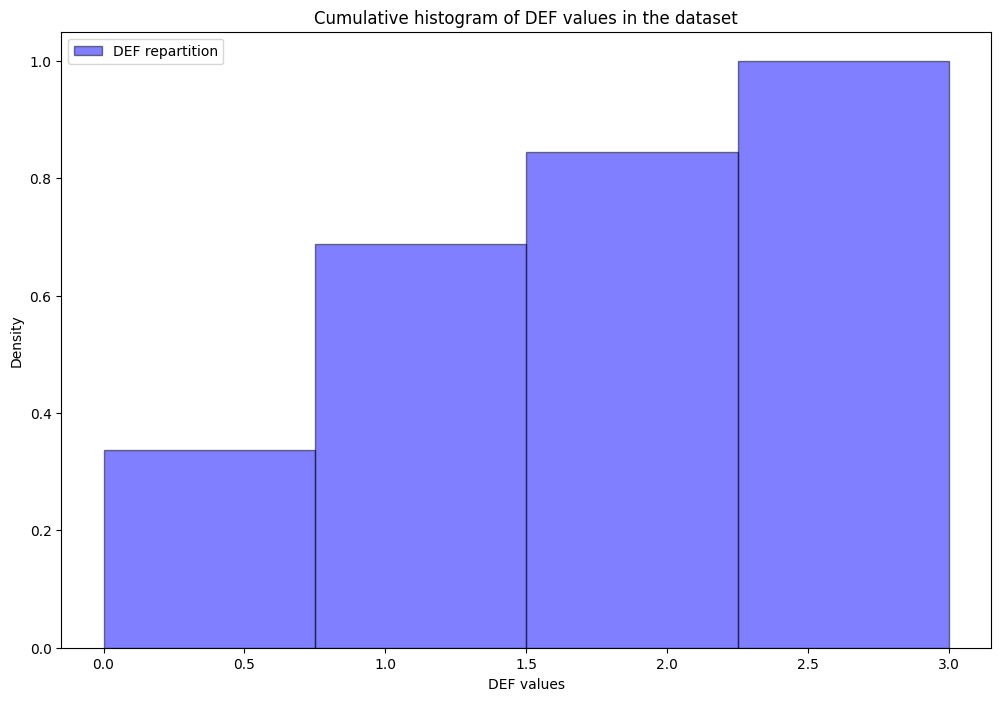

In [ ]:
#DEF data histogram
num_bins_def = 4

plt.figure(figsize=(12,8))
plt.hist(df['DEF_class'], bins=num_bins_def, cumulative=True, alpha=0.5, label='DEF repartition', color='blue', edgecolor='black', density=True)
plt.xlabel("DEF values")
plt.ylabel("Density")
plt.title("Cumulative histogram of DEF values in the dataset")
plt.legend()
plt.show()

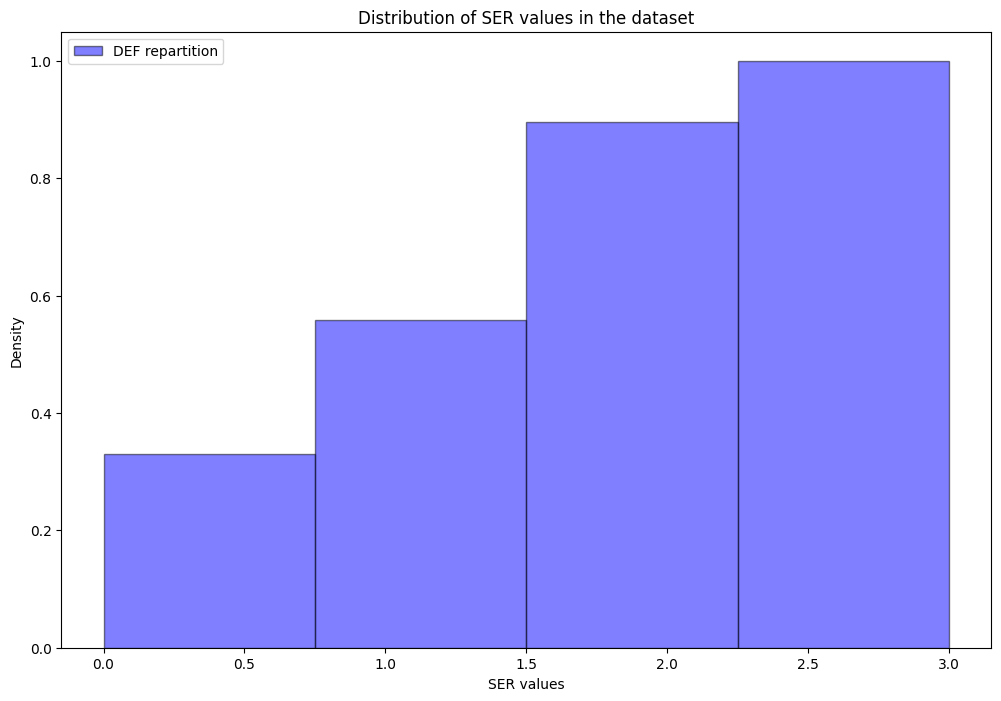

In [ ]:
#SER data histogram
num_bins_ser = 4

plt.figure(figsize=(12,8))
plt.hist(df['SER_class'], bins=num_bins_ser, cumulative=True, alpha=0.5, label='DEF repartition', color='blue', edgecolor='black', density=True)
plt.xlabel("SER values")
plt.ylabel("Density")
plt.title("Distribution of SER values in the dataset")
plt.legend()
plt.show()

**STEP 3 - MODEL SELECTION FOR PREDICTING DEF AND SER**

In this section, we implement two GridSearch CV, involving different ML models, a hyperparameters grid, and a pipeline providing feature standardization.

In [ ]:
#GridSearch CV for DEF_class

#Create ROC AUC score
def custom_roc_auc_score1(y_true, y_pred_proba):
  return roc_auc_score(y_true, y_pred_proba, multi_class='ovr')

roc_auc_scorer1 = make_scorer(custom_roc_auc_score1, needs_proba=True)


#List of ML classification models
models1 = {
    'RandomForest': RandomForestClassifier(),
    # 'SVC': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(),
    'MLPClassifier': MLPClassifier(max_iter=1000)
}

param_grids1 = {
    'RandomForest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    # 'SVC': {
    #     'model__C': [0.1, 1, 10],
    #     'model__gamma': ['scale', 'auto'],
    #     'model__kernel': ['linear', 'rbf', 'poly']
    # },
    'KNN': {
        'model__n_neighbors': [3, 5, 11],
        'model__weights': ['uniform', 'distance']
    },
    'NaiveBayes': {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7],
    },
    'LogisticRegression': {
        'model__C': [0.1, 1, 10],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear', 'saga']
    },
    'GradientBoosting': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7]
    },
    'MLPClassifier': {
        'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
        'model__activation': ['tanh', 'relu'],
        'model__solver': ['sgd', 'adam', 'rmsprop'],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate': ['constant', 'adaptive']
    }
}

scoring1 = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': roc_auc_scorer1,
    'f1': make_scorer(f1_score, average='macro', zero_divsion=0),
    'recall': make_scorer(recall_score, average='macro', zero_division=0),
    'precision': make_scorer(precision_score, average='macro', zero_division=0)
}

results1 = []

#GridSearchCV
for model_name1, model1 in models1.items():
  print(f"Training {model_name1}...")
  param_grid1 = param_grids1[model_name1]

  #Define pipeline and standardize features
  pipeline1 = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model1)
  ])

  cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  #Implement and fit GridSearchCV
  grid_search1 = GridSearchCV(estimator=pipeline1, param_grid=param_grid1, cv=cv1, scoring=scoring1, refit='roc_auc', n_jobs=-1, verbose=1)
  grid_search1.fit(x_train1, y_train1)

  #Collect scores
  best_model1 = grid_search1.best_estimator_
  best_params1 = grid_search1.best_params_
  best_score1 = grid_search1.best_score_
  y_train_pred1 = best_model1.predict(x_train1)
  y_train_pred_proba1 = best_model1.predict_proba(x_train1)

  train_accuracy1 = accuracy_score(y_train1, y_train_pred1)
  train_auc1 = roc_auc_score(y_train1, y_train_pred_proba1, multi_class='ovr')
  train_recall1 = recall_score(y_train1, y_train_pred1, average='macro')
  train_f1_score1 = f1_score(y_train1, y_train_pred1, average='macro')
  train_precision1 = precision_score(y_train1, y_train_pred1, average='macro')
  cv_results1 = grid_search1.cv_results_
  print(cv_results1.keys())
  best_index1 = grid_search1.best_index_
  mean_val_accuracy1 = cv_results1['mean_test_accuracy'][best_index1]
  std_val_accuracy1 = cv_results1['std_test_accuracy'][best_index1]
  mean_val_roc_auc1 = cv_results1['mean_test_roc_auc'][best_index1]
  mean_val_recall1 = cv_results1['mean_test_recall'][best_index1]
  mean_val_f1_score1 = cv_results1['mean_test_f1'][best_index1]
  mean_val_precision1 = cv_results1['mean_test_precision'][best_index1]
  results1.append({
      'Model': model_name1,
      'Best Params': grid_search1.best_params_,
      'Train Accuracy': train_accuracy1,
      'Train AUC': train_auc1,
      'Train Recall': train_recall1,
      'Train f1-score:': train_f1_score1,
      'Train Precision:': train_precision1,
      'Mean CV Accuracy': mean_val_accuracy1,
      'Std CV Accuracy': std_val_accuracy1,
      'CV AUC': mean_val_roc_auc1,
      'CV Recall': mean_val_recall1,
      'CV f1-score:': mean_val_f1_score1,
      'CV Precision:': mean_val_precision1
  })

  print(f"Best model for {model_name1}")
  print(f"Best hyperparameters: {best_params1}")
  print(f"Best Mean Val AUC: {best_score1:.4f}")
  print()

#Export GridSearchCV results to an Excel file
results1_df = pd.DataFrame(results1)
results1_df.to_excel('grid_search_results1.xlsx', index=False)
print("Results saved to grid_search_results1.xlsx")

Training RandomForest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__max_depth', 'param_model__min_samples_split', 'param_model__n_estimators', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'rank_test_roc_auc', 'split0_test_f1', 'split1_test_f1', 'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1', 'std_test_f1', 'rank_test_f1', 'split0_test_recall', 'split1_test_recall', 'split2_test_recall', 'split3_test_recall', 'split4_test_recall', 'mean_test_recall', 'std_test_recall', 'rank_test_recall', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'split4_test_precision', 'mean_test_precision', 'std

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan]
  warnings.warn(


dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__n_neighbors', 'param_model__weights', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'rank_test_roc_auc', 'split0_test_f1', 'split1_test_f1', 'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1', 'std_test_f1', 'rank_test_f1', 'split0_test_recall', 'split1_test_recall', 'split2_test_recall', 'split3_test_recall', 'split4_test_recall', 'mean_test_recall', 'std_test_recall', 'rank_test_recall', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'split4_test_precision', 'mean_test_precision', 'std_test_precision', 'rank_test_precisio

...

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan]
  warnings.warn(


dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__learning_rate', 'param_model__max_depth', 'param_model__n_estimators', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'rank_test_roc_auc', 'split0_test_f1', 'split1_test_f1', 'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1', 'std_test_f1', 'rank_test_f1', 'split0_test_recall', 'split1_test_recall', 'split2_test_recall', 'split3_test_recall', 'split4_test_recall', 'mean_test_recall', 'std_test_recall', 'rank_test_recall', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'split4_test_precision', 'mean_test_precision', 'std_tes

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 405, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 747, in fit
    self._validate_params()
  File "/usr/local/lib

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_model__activation', 'param_model__alpha', 'param_model__hidden_layer_sizes', 'param_model__learning_rate', 'param_model__solver', 'params', 'split0_test_accuracy', 'split1_test_accuracy', 'split2_test_accuracy', 'split3_test_accuracy', 'split4_test_accuracy', 'mean_test_accuracy', 'std_test_accuracy', 'rank_test_accuracy', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'mean_test_roc_auc', 'std_test_roc_auc', 'rank_test_roc_auc', 'split0_test_f1', 'split1_test_f1', 'split2_test_f1', 'split3_test_f1', 'split4_test_f1', 'mean_test_f1', 'std_test_f1', 'rank_test_f1', 'split0_test_recall', 'split1_test_recall', 'split2_test_recall', 'split3_test_recall', 'split4_test_recall', 'mean_test_recall', 'std_test_recall', 'rank_test_recall', 'split0_test_precision', 'split1_test_precision', 'split2_test_precision', 'split3_test_precision', 'spl

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#GridSearch CV for SER_class

#Create ROC AUC score
def custom_roc_auc_score2(y_true, y_pred_proba):
  return roc_auc_score(y_true, y_pred_proba, multi_class='ovr')

roc_auc_scorer2 = make_scorer(custom_roc_auc_score2, needs_proba=True)


#List of ML classification models
models2 = {
    'RandomForest': RandomForestClassifier(),
    'SVC': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'GradientBoosting': GradientBoostingClassifier(),
    'MLPClassifier': MLPClassifier(max_iter=1000)
}

param_grids2 = {
    'RandomForest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    'SVC': {
        'model__C': [0.1, 1, 10],
        'model__gamma': ['scale', 'auto'],
        'model__kernel': ['linear', 'rbf', 'poly']
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 11],
        'model__weights': ['uniform', 'distance']
    },
    'NaiveBayes': {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7],
    },
    'LogisticRegression': {
        'model__C': [0.1, 1, 10],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear', 'saga']
    },
    'GradientBoosting': {
        'model__n_estimators': [50, 100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5, 7]
    },
    'MLPClassifier': {
        'model__hidden_layer_sizes': [(50,), (100,), (100, 50)],
        'model__activation': ['tanh', 'relu'],
        'model__solver': ['sgd', 'adam', 'rmsprop'],
        'model__alpha': [0.0001, 0.001, 0.01],
        'model__learning_rate': ['constant', 'adaptive']
    }
}

scoring2 = {
    'accuracy': make_scorer(accuracy_score),
    'roc_auc': roc_auc_scorer1,
    'f1': make_scorer(f1_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro', zero_division=0),
    'precision': make_scorer(precision_score, average='macro', zero_division=0)
}

results2 = []

#GridSearchCV
for model_name2, model2 in models2.items():
  print(f"Training {model_name2}...")
  param_grid2 = param_grids2[model_name2]

  #Define pipeline and standardize features
  pipeline2 = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model2)
  ])

  cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

  #Implement and fit GridSearchCV
  grid_search2 = GridSearchCV(estimator=pipeline2, param_grid=param_grid2, cv=cv2, scoring=scoring2, refit='roc_auc', n_jobs=-1, verbose=1)
  grid_search2.fit(x_train2, y_train2)

  #Collect scores
  best_model2 = grid_search2.best_estimator_
  best_params2 = grid_search2.best_params_
  best_score2 = grid_search2.best_score_
  y_train_pred2 = best_model2.predict(x_train2)
  y_train_pred_proba2 = best_model2.predict_proba(x_train2)

  train_accuracy2 = accuracy_score(y_train2, y_train_pred2)
  train_auc2 = roc_auc_score(y_train2, y_train_pred_proba2, multi_class='ovr')
  train_recall2 = recall_score(y_train2, y_train_pred2, average='macro')
  train_f1_score2 = f1_score(y_train2, y_train_pred2, average='macro')
  train_precision2 = precision_score(y_train2, y_train_pred2, average='macro')
  cv_results2 = grid_search2.cv_results_
  best_index2 = grid_search2.best_index_
  mean_val_accuracy2 = cv_results2['mean_test_accuracy'][best_index2]
  std_val_accuracy2 = cv_results2['std_test_accuracy'][best_index2]
  mean_val_roc_auc2 = cv_results2['mean_test_roc_auc'][best_index2]
  mean_val_recall2 = cv_results2['mean_test_recall'][best_index2]
  mean_val_f1_score2 = cv_results2['mean_test_f1'][best_index2]
  mean_val_precision2 = cv_results2['mean_test_precision'][best_index2]
  results2.append({
      'Model': model_name2,
      'Best Params': grid_search2.best_params_,
      'Train Accuracy': train_accuracy2,
      'Train AUC': train_auc2,
      'Train Recall': train_recall2,
      'Train f1-score': train_f1_score2,
      'Train Precision': train_precision2,
      'Mean CV Accuracy': mean_val_accuracy2,
      'Std CV Accuracy': std_val_accuracy2,
      'CV AUC': mean_val_roc_auc2,
      'CV Recall': mean_val_recall2,
      'CV f1-score': mean_val_f1_score2,
      'CV Precision': mean_val_precision2
  })

  print(f"Best model for {model_name2}")
  print(f"Best hyperparameters: {best_params2}")
  print(f"Best Mean Val AUC: {best_score2:.4f}")
  print()

#Export GridSearchCV results to an Excel file
results2_df = pd.DataFrame(results2)
results2_df.to_excel('grid_search_results2.xlsx', index=False)
print("Results saved to grid_search_results2.xlsx")

Training RandomForest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best model for RandomForest
Best hyperparameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best Mean Val AUC: 0.7039

Training SVC...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best model for SVC
Best hyperparameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best Mean Val AUC: 0.7035

Training KNN...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best model for KNN
Best hyperparameters: {'model__n_neighbors': 3, 'model__weights': 'distance'}
Best Mean Val AUC: 0.6763

Training NaiveBayes...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best model for NaiveBayes
Best hyperparameters: {'model__var_smoothing': 1e-07}
Best Mean Val AUC: 0.6397

Training LogisticRegression...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best model for LogisticRegression
Best hyperparameters: {'mod

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
85 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 405, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py", line 747, in fit
    self._validate_params()
  File "/usr/local/lib

Best model for MLPClassifier
Best hyperparameters: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate': 'constant', 'model__solver': 'sgd'}
Best Mean Val AUC: 0.6928

Results saved to grid_search_results2.xlsx


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Plot distributions for DEF GridSearchCV
results_df1 = pd.read_excel('grid_search_results1.xlsx')

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Mean Validation MSE'], bins=np.linspace(0, 0.1, 100), edgecolor='black', range=(0, 0.1))
plt.title('Distribution of Mean Validation MSE')
plt.xlabel('Mean Validation MSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Std Validation MSE'], bins=np.linspace(0, 0.028, 100), edgecolor='black', range=(0, 0.028))
plt.title('Distribution of Validation MSE Standard Deviation')
plt.xlabel('Validation MSE Standard Deviation')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df1['Validation R2'], bins=np.linspace(0.35, 1, 100), edgecolor='black', range=(0,1))
plt.title('Distribution of Validation R²')
plt.xlabel('Validation R²')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
#Plot distributions for SER GridSearchCV
results_df2 = pd.read_excel('grid_search_results2.xlsx')

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Mean Validation MSE'], bins=np.linspace(0, 2000, 100), edgecolor='black', range=(0,2000))
plt.title('Distribution of Mean Validation MSE')
plt.xlabel('Mean Validation MSE')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Std Validation MSE'], bins=np.linspace(0, 100, 100), edgecolor='black', range=(0,100))
plt.title('Distribution of Validation MSE Standard Deviation')
plt.xlabel('Validation MSE Standard Deviation')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(results_df2['Validation R2'], bins=np.linspace(0.20, 0.6, 100), edgecolor='black', range=(0,1))
plt.title('Distribution of Validation R²')
plt.xlabel('Validation R²')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**STEP 4 - DEFINE THE BEST ML MODELS**

In this section, we define the best model for DEF and for SER prediction, with the optimal hyperparameters. Two approaches are proposed here: first a definition of a single model for each prediction, then an ensembling method for each prediction.

***Single model approach***

In [ ]:
#Define best single model for DEF_class prediction - RandomForest
best_model1 = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    random_state = 42,
    verbose = 0
)

#Fit the model to the train subset
best_model1.fit(x_train1, y_train1)

RandomForestClassifier(random_state=42)

In [ ]:
#Define best single model for SER prediction - CatBoost
best_model2 = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 10,
    random_state = 42,
    verbose = 0
)

#Fit the model to train subset
best_model2.fit(x_train2, y_train2)

RandomForestClassifier(max_depth=10, random_state=42)

***Ensembling approach***

In [ ]:
#Define ensembling model for DEF_class prediction

#Approach based on ROC AUC score
#Model 1a: RandomForest
best_model1a = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    min_samples_split = 5,
    verbose = 0,
    random_state = 42
)

#Model 1b: GradientBossting
best_model1b = GradientBoostingClassifier(
    n_estimators = 100,
    max_depth = 7,
    learning_rate = 0.2,
    verbose = 0,
    random_state = 42
)

#Fit the model to the train subset
best_model1a.fit(x_train1, y_train1)
best_model1b.fit(x_train1, y_train1)

GradientBoostingClassifier(learning_rate=0.2, max_depth=7, random_state=42)

In [ ]:
#Define ensembling model for SER prediction

#Approach based on ROC AUC score
#Model 2a: RandomForest
best_model2a = RandomForestClassifier(
    n_estimators = 50,
    max_depth = 20,
    min_samples_split = 2,
    verbose = 0,
    random_state = 42
)

#Model 2b: MLPClassifier
best_model2b = MLPClassifier(
    hidden_layer_sizes = (100,50),
    activation = 'relu',
    solver = 'sgd',
    alpha = 0.0001,
    learning_rate = 'constant',
    verbose = 0,
    random_state = 42
)

#Fit the model to train subset
best_model2a.fit(x_train2, y_train2)
best_model2b.fit(x_train2, y_train2)

MLPClassifier(hidden_layer_sizes=(100, 50), random_state=42, solver='sgd',
              verbose=0)

**STEP 5 - K-FOLD CROSS-VALIDATION**

In this section, a cross-validation (k=5) is performed in order to assess performance and stability of the model on the train set. In the end, different folds from the train set are regrouped in order to see the predictions on the full train set.

***Single model approach***

In [ ]:
#Cross Validation on single model DEF_class Predictor

#Convert Numpy arrays into Pandas DataFrames
x_train_df1 = pd.DataFrame(x_train1, columns=x_data.columns)
y_train_df1 = pd.DataFrame(y_train1).reset_index(drop=True)

#Define K-fold CV
group_kfold1 = GroupKFold(n_splits=5)

predicted_values1 = np.zeros_like(y_train1)
actual_values1 = np.zeros_like(y_train1)
train_accuracy_scores1 = []
val_accuracy_scores1 = []

#Perform K-fold CV
for fold_idx, (train_index, val_index) in enumerate(group_kfold1.split(x_train_df1, y_train_df1, groups=x_train_df1['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df1, x_val_fold_df1 = x_train_df1.iloc[train_index], x_train_df1.iloc[val_index]
  y_train_fold_df1, y_val_fold_df1 = y_train_df1.iloc[train_index], y_train_df1.iloc[val_index]
  exp_val1 = train_df1['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold1 = x_train_fold_df1.values
  x_val_fold1 = x_val_fold_df1.values
  y_train_fold1 = y_train_fold_df1.values
  y_val_fold1 = y_val_fold_df1.values

  y_train_fold1 = np.ravel(y_train_fold1)
  y_val_fold1 = np.ravel(y_val_fold1)

  #Scale data
  scaler_x_train1 = StandardScaler()
  scaler_x_val1 = StandardScaler()

  x_train_fold_scaled1 = scaler_x_train1.fit_transform(x_train_fold1)
  x_val_fold_scaled1 = scaler_x_val1.fit_transform(x_val_fold1)

  #Fit best model
  best_model1.fit(x_train_fold_scaled1, y_train_fold1)

  #Make predictions
  y_train_pred1 = best_model1.predict(x_train_fold_scaled1)
  y_val_pred1 = best_model1.predict(x_val_fold_scaled1)


  #Collect CV results
  train_accuracy1 = accuracy_score(y_train_fold1, y_train_pred1)
  val_accuracy1 = accuracy_score(y_val_fold1, y_val_pred1)
  train_accuracy_scores1.append(train_accuracy1)
  val_accuracy_scores1.append(val_accuracy1)
  print(f"Fold {fold_idx + 1} Train Accuracy: {train_accuracy1}, Validation Accuracy: {val_accuracy1}")

  #Store CV results
  predicted_values1[val_index] = y_val_pred1.flatten()
  actual_values1[val_index] = y_val_fold1.flatten()

  results_df1 = pd.DataFrame({
      'Exp': train_exp1,
      'Actual DEF': actual_values1.flatten(),
      'Predicted DEF': predicted_values1.flatten()
  })

results_df1.to_excel('predicted_values_cv1.xlsx', index=False)

#CV metrics
mean_train_accuracy1 = np.mean(train_accuracy_scores1)
std_train_accuracy1 = np.std(train_accuracy_scores1)

mean_val_accuracy1 = np.mean(val_accuracy_scores1)
std_val_accuracy1 = np.std(val_accuracy_scores1)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for DEF_class Predictor:")
print("Mean Accuracy:", mean_train_accuracy1)
print("Standard Deviation of Accuracy:", std_train_accuracy1)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for DEF_class Predictor:")
print("Mean Accuracy:", mean_val_accuracy1)
print("Standard Deviation of MSE:", std_val_accuracy1)

Fold 1
Fold 1 Train Accuracy: 0.9802955665024631, Validation Accuracy: 0.375
Fold 2
Fold 2 Train Accuracy: 0.988929889298893, Validation Accuracy: 0.4264705882352941
Fold 3
Fold 3 Train Accuracy: 0.9894366197183099, Validation Accuracy: 0.32727272727272727
Fold 4
Fold 4 Train Accuracy: 0.9829351535836177, Validation Accuracy: 0.30434782608695654
Fold 5
Fold 5 Train Accuracy: 0.9836065573770492, Validation Accuracy: 0.3235294117647059

Metrics for Train Set for DEF_class Predictor:
Mean Accuracy: 0.9850407572960667
Standard Deviation of Accuracy: 0.00356247908737685

Metrics for Validation Set for DEF_class Predictor:
Mean Accuracy: 0.3513241106719368
Standard Deviation of MSE: 0.044193498322317296


In [ ]:
#Cross Validation on single model SER_class Predictor

#Convert Numpy arrays into Pandas DataFrames
x_train_df2 = pd.DataFrame(x_train2, columns=x_data.columns)
y_train_df2 = pd.DataFrame(y_train2).reset_index(drop=True)

#Define K-fold CV
group_kfold2 = GroupKFold(n_splits=5)

predicted_values2 = np.zeros_like(y_train2)
actual_values2 = np.zeros_like(y_train2)
train_accuracy_scores2 = []
val_accuracy_scores2 = []

#Perform K-fold CV
for fold_idx, (train_index, val_index) in enumerate(group_kfold2.split(x_train_df2, y_train_df2, groups=x_train_df2['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df2, x_val_fold_df2 = x_train_df2.iloc[train_index], x_train_df2.iloc[val_index]
  y_train_fold_df2, y_val_fold_df2 = y_train_df2.iloc[train_index], y_train_df2.iloc[val_index]
  exp_val2 = train_df2['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold2 = x_train_fold_df2.values
  x_val_fold2 = x_val_fold_df2.values
  y_train_fold2 = y_train_fold_df2.values
  y_val_fold2 = y_val_fold_df2.values

  y_train_fold2 = np.ravel(y_train_fold2)
  y_val_fold2 = np.ravel(y_val_fold2)

  #Scale data
  scaler_x_train2 = StandardScaler()
  scaler_x_val2 = StandardScaler()

  x_train_fold_scaled2 = scaler_x_train2.fit_transform(x_train_fold2)
  x_val_fold_scaled2 = scaler_x_val2.fit_transform(x_val_fold2)

  #Fit best model
  best_model2.fit(x_train_fold_scaled2, y_train_fold2)

  #Make predictions
  y_train_pred2 = best_model2.predict(x_train_fold_scaled2)
  y_val_pred2 = best_model2.predict(x_val_fold_scaled2)


  #Collect CV results
  train_accuracy2 = accuracy_score(y_train_fold2, y_train_pred2)
  val_accuracy2 = accuracy_score(y_val_fold2, y_val_pred2)
  train_accuracy_scores2.append(train_accuracy2)
  val_accuracy_scores2.append(val_accuracy2)
  print(f"Fold {fold_idx + 1} Train Accuracy: {train_accuracy2}, Validation Accuracy: {val_accuracy2}")

  #Store CV results
  predicted_values2[val_index] = y_val_pred2.flatten()
  actual_values2[val_index] = y_val_fold2.flatten()

  results_df2 = pd.DataFrame({
      'Exp': train_exp2,
      'Actual SER': actual_values2.flatten(),
      'Predicted SER': predicted_values2.flatten()
  })

results_df2.to_excel('predicted_values_cv2.xlsx', index=False)

#CV metrics
mean_train_accuracy2 = np.mean(train_accuracy_scores2)
std_train_accuracy2 = np.std(train_accuracy_scores2)

mean_val_accuracy2 = np.mean(val_accuracy_scores2)
std_val_accuracy2 = np.std(val_accuracy_scores2)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for SER_class Predictor:")
print("Mean Accuracy:", mean_train_accuracy2)
print("Standard Deviation of Accuracy:", std_train_accuracy2)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for SER_class Predictor:")
print("Mean Accuracy:", mean_val_accuracy2)
print("Standard Deviation of MSE:", std_val_accuracy2)

Fold 1
Fold 1 Train Accuracy: 0.9655172413793104, Validation Accuracy: 0.3897058823529412
Fold 2
Fold 2 Train Accuracy: 0.974169741697417, Validation Accuracy: 0.25
Fold 3
Fold 3 Train Accuracy: 0.9647887323943662, Validation Accuracy: 0.4
Fold 4
Fold 4 Train Accuracy: 0.962457337883959, Validation Accuracy: 0.32608695652173914
Fold 5
Fold 5 Train Accuracy: 0.9475409836065574, Validation Accuracy: 0.14705882352941177

Metrics for Train Set for SER_class Predictor:
Mean Accuracy: 0.962894807392322
Standard Deviation of Accuracy: 0.008643142251852011

Metrics for Validation Set for SER_class Predictor:
Mean Accuracy: 0.3025703324808184
Standard Deviation of MSE: 0.0944305512471305


***Ensembling approach***

In [ ]:
#Transform Ensemble DEF_class predictions into a regular model

#Train independant models on the whole Train Set
final_model1a = best_model1a.fit(x_train1, y_train1)
final_model1b = best_model1b.fit(x_train1, y_train1)

#Define optimal weights for each model on the ensembling
optimized_weights1 = [0.50, 0.50]

#Define ensemble classifier
class EnsembleClassifier1:
  def __init__(self, models, weights):
    self.models = models
    self.weights = weights

  def fit(self, x_train1, y_train1):
    for model in self.models:
      model.fit(x_train1, y_train1)

  def predict(self, x_train1):
    weighted_predictions1 = np.zeros((x_train1.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_predictions1 += weight * model.predict_proba(x_train1)
    return np.argmax(weighted_predictions1, axis=1)

  def predict_proba(self, x_train1):
    weighted_predictions1 = np.zeros((x_train1.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_predictions1 += weight * model.predict_proba(x_train1)
    return weighted_predictions1 / np.sum(self.weights)

#Define and fit ensemble model
ensemble_model1 = EnsembleClassifier1(models=[final_model1a, final_model1b], weights=optimized_weights1)
ensemble_model1.fit(x_train1, y_train1)
ensemble_model1.predict(x_train1)

#Convert Numpy arrays into Pandas DataFrames
x_train_df1 = pd.DataFrame(x_train1, columns=x_data.columns)
y_train_df1 = pd.DataFrame(y_train1).reset_index(drop=True)

#Define K-fold CV
group_kfold1 = GroupKFold(n_splits=5)

predicted_values1 = np.zeros_like(y_train1)
actual_values1 = np.zeros_like(y_train1)
train_accuracy_scores1 = []
val_accuracy_scores1 = []
train_auc_scores1 = []
val_auc_scores1 = []

#Perform K-fold CV
for fold_idx, (train_index, val_index) in enumerate(group_kfold1.split(x_train_df1, y_train_df1, groups=x_train_df1['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df1, x_val_fold_df1 = x_train_df1.iloc[train_index], x_train_df1.iloc[val_index]
  y_train_fold_df1, y_val_fold_df1 = y_train_df1.iloc[train_index], y_train_df1.iloc[val_index]
  exp_val1 = train_df1['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold1 = x_train_fold_df1.values
  x_val_fold1 = x_val_fold_df1.values
  y_train_fold1 = y_train_fold_df1.values
  y_val_fold1 = y_val_fold_df1.values

  #Convert y into a 1D array
  y_train_fold1 = np.ravel(y_train_fold1)
  y_val_fold1 = np.ravel(y_val_fold1)

  #Scale data
  scaler_x_train1 = StandardScaler()
  scaler_x_val1 = StandardScaler()

  x_train_fold_scaled1 = scaler_x_train1.fit_transform(x_train_fold1)
  x_val_fold_scaled1 = scaler_x_val1.fit_transform(x_val_fold1)

  #Fit ensemble model
  ensemble_model1.fit(x_train_fold_scaled1, y_train_fold1)

  #Make predictions
  y_train_pred1 = ensemble_model1.predict(x_train_fold_scaled1)
  y_train_fold_pred_proba1 = ensemble_model1.predict_proba(x_train_fold_scaled1)
  y_val_pred1 = ensemble_model1.predict(x_val_fold_scaled1)
  y_val_fold_pred_proba1 = ensemble_model1.predict_proba(x_val_fold_scaled1)


  #Collect CV results
  train_accuracy1 = accuracy_score(y_train_fold1, y_train_pred1)
  val_accuracy1 = accuracy_score(y_val_fold1, y_val_pred1)
  train_accuracy_scores1.append(train_accuracy1)
  val_accuracy_scores1.append(val_accuracy1)

  train_auc1 = roc_auc_score(y_train_fold1, y_train_fold_pred_proba1, multi_class='ovr')
  val_auc1 = roc_auc_score(y_val_fold1, y_val_fold_pred_proba1, multi_class='ovr')
  train_auc_scores1.append(train_auc1)
  val_auc_scores1.append(val_auc1)

  print(f"Fold {fold_idx + 1} - Train Accuracy: {train_accuracy1}, Validation Accuracy: {val_accuracy1}")
  print(f"Fold {fold_idx + 1} - Train AUC: {train_auc1}, Validation AUC: {val_auc1}")

  #Store CV results
  predicted_values1[val_index] = y_val_pred1.flatten()
  actual_values1[val_index] = y_val_fold1.flatten()

  results_df1 = pd.DataFrame({
      'Exp': train_exp1,
      'Actual DEF': actual_values1.flatten(),
      'Predicted DEF': predicted_values1.flatten()
  })

results_df1.to_excel('predicted_values_cv1.xlsx', index=False)

#CV metrics
mean_train_accuracy1 = np.mean(train_accuracy_scores1)
std_train_accuracy1 = np.std(train_accuracy_scores1)

mean_val_accuracy1 = np.mean(val_accuracy_scores1)
std_val_accuracy1 = np.std(val_accuracy_scores1)

mean_train_auc1 = np.mean(train_auc_scores1)
std_train_auc1 = np.std(train_auc_scores1)

mean_val_auc1 = np.mean(val_auc_scores1)
std_val_auc1 = np.std(val_auc_scores1)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for DEF_class Predictor:")
print("Mean Accuracy:", mean_train_accuracy1)
print("Standard Deviation of Accuracy:", std_train_accuracy1)
print("Mean AUC:", mean_train_auc1)
print("Standard Deviation of AUC:", std_train_auc1)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for DEF_class Predictor:")
print("Mean Accuracy:", mean_val_accuracy1)
print("Standard Deviation of Accuracy:", std_val_accuracy1)
print("Mean AUC:", mean_val_auc1)
print("Standard Deviation of AUC:", std_val_auc1)

Fold 1
Fold 1 - Train Accuracy: 0.9950738916256158, Validation Accuracy: 0.33088235294117646
Fold 1 - Train AUC: 0.9999622578516969, Validation AUC: 0.5770774142313414
Fold 2
Fold 2 - Train Accuracy: 0.988929889298893, Validation Accuracy: 0.3382352941176471
Fold 2 - Train AUC: 0.9998553930982507, Validation AUC: 0.6274461686593712
Fold 3
Fold 3 - Train Accuracy: 0.9929577464788732, Validation Accuracy: 0.2545454545454545
Fold 3 - Train AUC: 0.9999304145280251, Validation AUC: 0.561671221334062
Fold 4
Fold 4 - Train Accuracy: 0.9897610921501706, Validation Accuracy: 0.2391304347826087
Fold 4 - Train AUC: 0.9998639117523411, Validation AUC: 0.5216352049467975
Fold 5
Fold 5 - Train Accuracy: 0.9901639344262295, Validation Accuracy: 0.29411764705882354
Fold 5 - Train AUC: 0.9998742803138149, Validation AUC: 0.47007906445406444

Metrics for Train Set for DEF_class Predictor:
Mean Accuracy: 0.9913773107959564
Standard Deviation of Accuracy: 0.0022907118408008968
Mean AUC: 0.9998972515088257

In [ ]:
#Transform Ensemble SER_class predictions into a regular model

#Train independant models on the whole Train Set
final_model2a = best_model2a.fit(x_train2, y_train2)
final_model2b = best_model2b.fit(x_train2, y_train2)

#Define optimal weights for each model on the ensembling
optimized_weights2 = [0.50, 0.50]

#Define ensemble classifier
class EnsembleClassifier2:
  def __init__(self, models, weights):
    self.models = models
    self.weights = weights

  def fit(self, x_train2, y_train2):
    for model in self.models:
      model.fit(x_train2, y_train2)

  def predict(self, x_train2):
    weighted_predictions2 = np.zeros((x_train2.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_predictions2 += weight * model.predict_proba(x_train2)
    return np.argmax(weighted_predictions2, axis=1)

  def predict_proba(self, x_train2):
    weighted_predictions2 = np.zeros((x_train2.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_predictions2 += weight * model.predict_proba(x_train2)
    return weighted_predictions2 / np.sum(self.weights)

#Define and fit ensemble model
ensemble_model2 = EnsembleClassifier2(models=[final_model2a, final_model2b], weights=optimized_weights2)
ensemble_model1.fit(x_train1, y_train1)
ensemble_model2.predict(x_train2)

#Convert Numpy arrays into Pandas DataFrames
x_train_df2 = pd.DataFrame(x_train2, columns=x_data.columns)
y_train_df2 = pd.DataFrame(y_train2).reset_index(drop=True)

#Define K-fold CV
group_kfold2 = GroupKFold(n_splits=5)

predicted_values2 = np.zeros_like(y_train2)
actual_values2 = np.zeros_like(y_train2)
train_accuracy_scores2 = []
val_accuracy_scores2 = []
train_auc_scores2 = []
val_auc_scores2 = []

#Perform K-fold CV
for fold_idx, (train_index, val_index) in enumerate(group_kfold2.split(x_train_df2, y_train_df2, groups=x_train_df2['Cell_type'])):
  print(f"Fold {fold_idx + 1}")

  #Split data into Training and Validation folds
  x_train_fold_df2, x_val_fold_df2 = x_train_df2.iloc[train_index], x_train_df2.iloc[val_index]
  y_train_fold_df2, y_val_fold_df2 = y_train_df2.iloc[train_index], y_train_df2.iloc[val_index]
  exp_val2 = train_df2['Exp'].iloc[val_index].values

  #Convert DataFrames back to Numpy arrays
  x_train_fold2 = x_train_fold_df2.values
  x_val_fold2 = x_val_fold_df2.values
  y_train_fold2 = y_train_fold_df2.values
  y_val_fold2 = y_val_fold_df2.values

  #Convert y into a 1D array
  y_train_fold2 = np.ravel(y_train_fold2)
  y_val_fold2 = np.ravel(y_val_fold2)

  #Scale data
  scaler_x_train2 = StandardScaler()
  scaler_x_val2 = StandardScaler()

  x_train_fold_scaled2 = scaler_x_train2.fit_transform(x_train_fold2)
  x_val_fold_scaled2 = scaler_x_val2.fit_transform(x_val_fold2)

  #Fit ensemble model
  ensemble_model2.fit(x_train_fold_scaled2, y_train_fold2)

  #Make predictions
  y_train_pred2 = ensemble_model2.predict(x_train_fold_scaled2)
  y_train_fold_pred_proba2 = ensemble_model2.predict_proba(x_train_fold_scaled2)
  y_val_pred2 = ensemble_model2.predict(x_val_fold_scaled2)
  y_val_fold_pred_proba2 = ensemble_model2.predict_proba(x_val_fold_scaled2)


  #Collect CV results
  train_accuracy2 = accuracy_score(y_train_fold2, y_train_pred2)
  val_accuracy2 = accuracy_score(y_val_fold2, y_val_pred2)
  train_accuracy_scores2.append(train_accuracy2)
  val_accuracy_scores2.append(val_accuracy2)

  train_auc2 = roc_auc_score(y_train_fold2, y_train_fold_pred_proba2, multi_class='ovr')
  val_auc2 = roc_auc_score(y_val_fold2, y_val_fold_pred_proba2, multi_class='ovr')

  print(f"Fold {fold_idx + 1} - Train Accuracy: {train_accuracy2}, Validation Accuracy: {val_accuracy2}")
  print(f"Fold {fold_idx + 1} - Train AUC: {train_auc2}, Validation AUC: {val_auc2}")

  #Store CV results
  predicted_values2[val_index] = y_val_pred2.flatten()
  actual_values2[val_index] = y_val_fold2.flatten()

  results_df2 = pd.DataFrame({
      'Exp': train_exp2,
      'Actual SER': actual_values2.flatten(),
      'Predicted SER': predicted_values2.flatten()
  })

results_df2.to_excel('predicted_values_cv2.xlsx', index=False)

#CV metrics
mean_train_accuracy2 = np.mean(train_accuracy_scores2)
std_train_accuracy2 = np.std(train_accuracy_scores2)

mean_val_accuracy2 = np.mean(val_accuracy_scores2)
std_val_accuracy2 = np.std(val_accuracy_scores2)

mean_train_auc2 = np.mean(train_auc_scores2)
std_train_auc2 = np.std(train_auc_scores2)

mean_val_auc2 = np.mean(val_auc_scores2)
std_val_auc2 = np.std(val_auc_scores2)

#Print metrics for Train subset
print("")
print("Metrics for Train Set for SER_class Predictor:")
print("Mean Accuracy:", mean_train_accuracy2)
print("Standard Deviation of Accuracy:", std_train_accuracy2)
print("Mean AUC:", mean_train_auc2)
print("Standard Deviation of AUC:", std_train_auc2)
print("")

#Print metrics for Validation subset
print("Metrics for Validation Set for SER_class Predictor:")
print("Mean Accuracy:", mean_val_accuracy2)
print("Standard Deviation of Accuracy:", std_val_accuracy2)
print("Mean AUC:", mean_val_auc2)
print("Standard Deviation of AUC:", std_val_auc2)

Fold 1


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 - Train Accuracy: 0.9556650246305419, Validation Accuracy: 0.4117647058823529
Fold 1 - Train AUC: 0.9976907928067291, Validation AUC: 0.6744128018763971
Fold 2


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2 - Train Accuracy: 0.9520295202952029, Validation Accuracy: 0.27941176470588236
Fold 2 - Train AUC: 0.9960670077792793, Validation AUC: 0.6276530536632907
Fold 3


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 3 - Train Accuracy: 0.9788732394366197, Validation Accuracy: 0.32727272727272727
Fold 3 - Train AUC: 0.9987667861541805, Validation AUC: 0.5982205404851841
Fold 4


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 4 - Train Accuracy: 0.9453924914675768, Validation Accuracy: 0.30434782608695654
Fold 4 - Train AUC: 0.9967848138532749, Validation AUC: 0.48795888142747074
Fold 5
Fold 5 - Train Accuracy: 0.9639344262295082, Validation Accuracy: 0.35294117647058826
Fold 5 - Train AUC: 0.9980138330343451, Validation AUC: 0.5905893766674751

Metrics for Train Set for SER_class Predictor:
Mean Accuracy: 0.9591789404118899
Standard Deviation of Accuracy: 0.011523958053155967
Mean AUC: nan
Standard Deviation of AUC: nan

Metrics for Validation Set for SER_class Predictor:
Mean Accuracy: 0.3351476400837015
Standard Deviation of Accuracy: 0.04539584850378427
Mean AUC: nan
Standard Deviation of AUC: nan


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid val

**STEP 6 - ANALYZE PREDICTIONS ON FULL TRAINING SET**

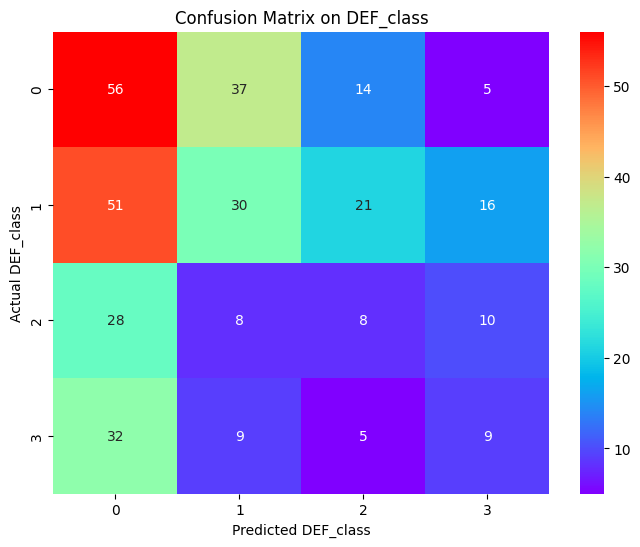

              precision    recall  f1-score   support

           0       0.34      0.50      0.40       112
           1       0.36      0.25      0.30       118
           2       0.17      0.15      0.16        54
           3       0.23      0.16      0.19        55

    accuracy                           0.30       339
   macro avg       0.27      0.27      0.26       339
weighted avg       0.30      0.30      0.29       339



In [ ]:
#Confusion matrix on DEF_class
#Import CV predictions
data_cv1 = pd.read_excel("predicted_values_cv1.xlsx")

#Define input and output
x_data_cv1 = data_cv1['Actual DEF']
y_data_cv1 = data_cv1['Predicted DEF']

cm1 = confusion_matrix(x_data_cv1, y_data_cv1)

plt.figure(figsize=(8,6))
sns.heatmap(cm1, annot=True, cmap='rainbow', fmt='g', cbar='True')
plt.xlabel("Predicted DEF_class")
plt.ylabel("Actual DEF_class")
plt.title("Confusion Matrix on DEF_class")
plt.show()

#Print classification report
print(classification_report(x_data_cv1, y_data_cv1))

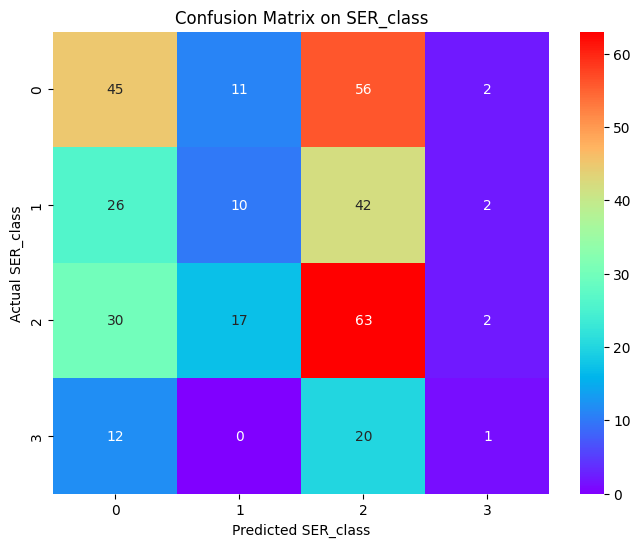

              precision    recall  f1-score   support

           0       0.40      0.39      0.40       114
           1       0.26      0.12      0.17        80
           2       0.35      0.56      0.43       112
           3       0.14      0.03      0.05        33

    accuracy                           0.35       339
   macro avg       0.29      0.28      0.26       339
weighted avg       0.32      0.35      0.32       339



In [ ]:
#Confusion matrix on SER_class
#Import CV predictions
data_cv2 = pd.read_excel("predicted_values_cv2.xlsx")

#Define input and output
x_data_cv2 = data_cv2['Actual SER']
y_data_cv2 = data_cv2['Predicted SER']

cm2 = confusion_matrix(x_data_cv2, y_data_cv2)

plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, cmap='rainbow', fmt='g', cbar='True')
plt.xlabel("Predicted SER_class")
plt.ylabel("Actual SER_class")
plt.title("Confusion Matrix on SER_class")
plt.show()

#Print classification report
print(classification_report(x_data_cv2, y_data_cv2))

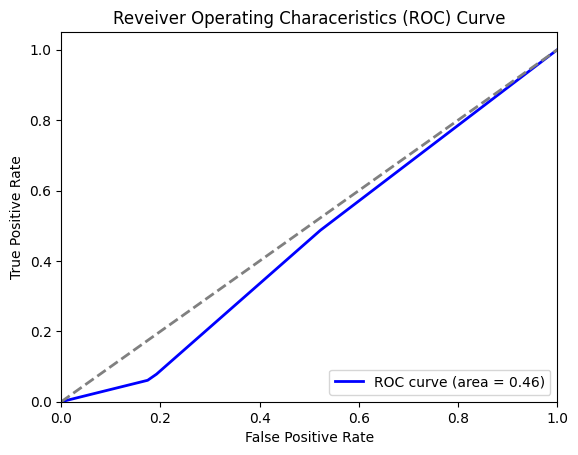

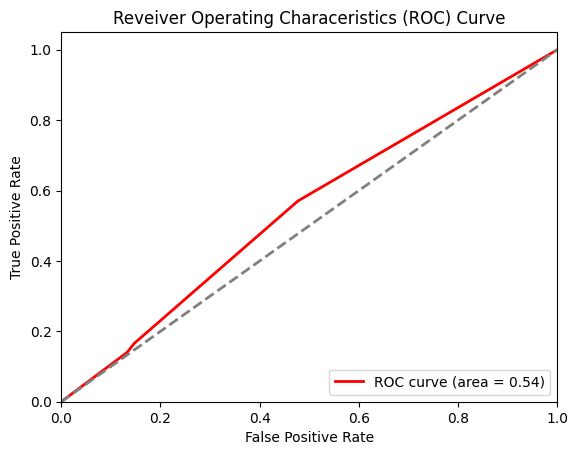

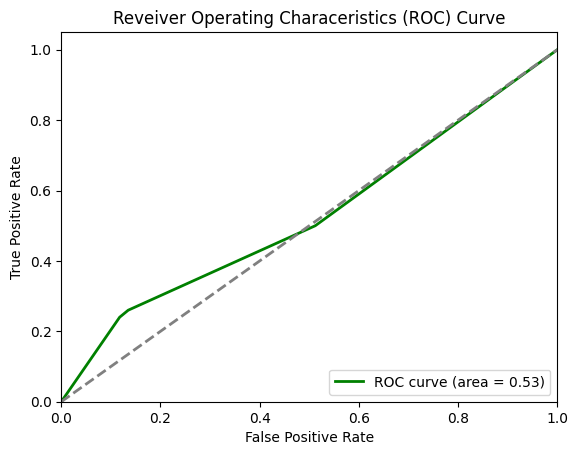

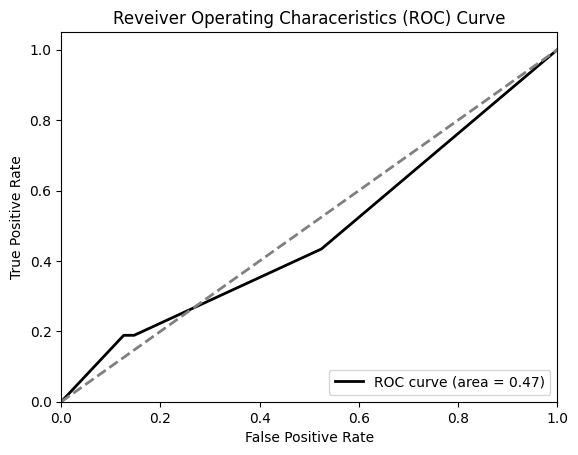

In [ ]:
#ROC curve on DEF_class
n_classes1 = 4

fpr1 = dict()
tpr1 = dict()
roc_auc1 = dict()
for i in range(n_classes1):
  fpr1[i], tpr1[i], _1 = roc_curve((x_data_cv1 == i).astype(int), y_data_cv1)
  roc_auc1[i] = auc(fpr1[i], tpr1[i])

plt.figure()
colors1 = ['blue', 'red', 'green', 'black']
for i, color1 in zip(range(n_classes1), colors1):
  plt.plot(fpr1[i], tpr1[i], color=color1, lw=2, label='ROC curve (area = %0.2f)' % roc_auc1[i])
  plt.plot([0,1], [0,1], color='gray', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Reveiver Operating Characeristics (ROC) Curve")
  plt.legend(loc='lower right')
  plt.show()

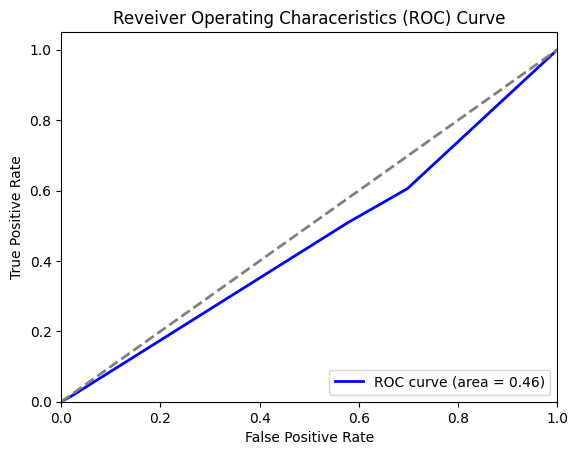

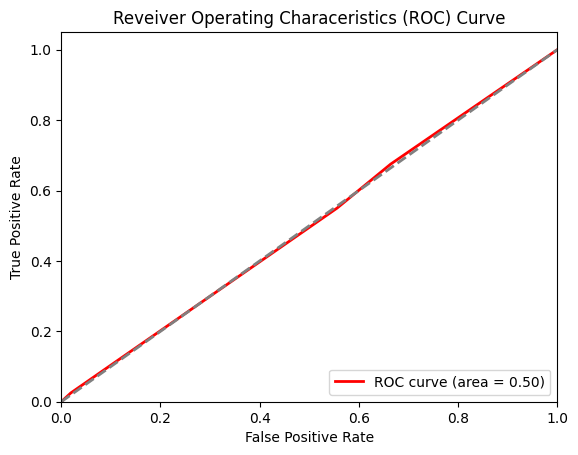

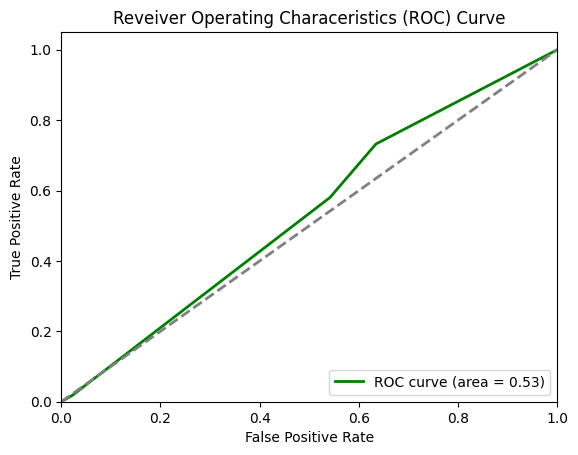

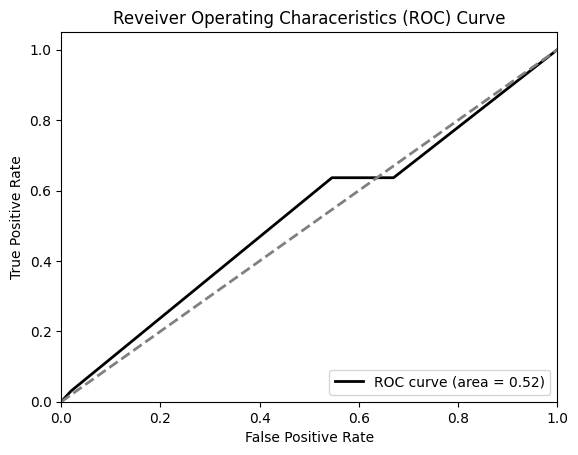

In [ ]:
#ROC curve on SER_class
n_classes2 = 4

fpr2 = dict()
tpr2 = dict()
roc_auc2 = dict()
for i in range(n_classes2):
  fpr2[i], tpr2[i], _1 = roc_curve((x_data_cv2 == i).astype(int), y_data_cv2)
  roc_auc2[i] = auc(fpr2[i], tpr2[i])

plt.figure()
colors2 = ['blue', 'red', 'green', 'black']
for i, color2 in zip(range(n_classes2), colors2):
  plt.plot(fpr2[i], tpr2[i], color=color2, lw=2, label='ROC curve (area = %0.2f)' % roc_auc2[i])
  plt.plot([0,1], [0,1], color='gray', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("Reveiver Operating Characeristics (ROC) Curve")
  plt.legend(loc='lower right')
  plt.show()

**STEP 7 - FULL MODEL TRAINING**

In this section, every final model is trained on the full training subset.

***Single model approach***

In [ ]:
#Final single model for DEF_class prediction

scaler_x_final1 = StandardScaler()
scaler_y_final1 = StandardScaler()

x_train_scaled1 = scaler_x_final1.fit_transform(x_train1)

#Fit final single model
final_model1 = best_model1
final_model1.fit(x_train_scaled1, y_train1)

y_train_pred_final1 = final_model1.predict(x_train_scaled1)

#Print final metric
final_accuracy1 = accuracy_score(y_train1, y_train_pred_final1)
print("Final DEF_class Model Accuracy:", final_accuracy1)

Final DEF_class Model Accuracy: 0.9852507374631269


In [ ]:
#Final single model for SER_class prediction

scaler_x_final2 = StandardScaler()
scaler_y_final2 = StandardScaler()

x_train_scaled2 = scaler_x_final2.fit_transform(x_train2)

#Fit final single model
final_model2 = best_model2
final_model2.fit(x_train_scaled2, y_train2)

y_train_pred_final2 = final_model2.predict(x_train_scaled2)

#Print final metric
final_accuracy2 = accuracy_score(y_train2, y_train_pred_final2)
print("Final SER_class Model Accuracy:", final_accuracy2)

Final SER_class Model Accuracy: 0.9469026548672567


***Ensembling approach***

In [ ]:
#Final ensembling model for DEF_class prediction

scaler_x_final1 = StandardScaler()
scaler_y_final1 = StandardScaler()

x_train_scaled1 = scaler_x_final1.fit_transform(x_train1)

#Fit final ensembling model
final_model1 = ensemble_model1
final_model1.fit(x_train_scaled1, y_train1)

y_train_pred_final1 = final_model1.predict(x_train_scaled1)

#Print final metric
final_accuracy1 = accuracy_score(y_train1, y_train_pred_final1)
print("Final DEF_class Model Accuracy:", final_accuracy1)

Final DEF_class Model Accuracy: 0.9911504424778761


In [ ]:
#Final ensembling model on SER_class prediction

scaler_x_final2 = StandardScaler()
scaler_y_final2 = StandardScaler()

x_train_scaled2 = scaler_x_final2.fit_transform(x_train2)

#Fit final single model
final_model2 = ensemble_model2
final_model2.fit(x_train_scaled2, y_train2)

y_train_pred_final2 = final_model2.predict(x_train_scaled2)

#Print final metric
final_accuracy2 = accuracy_score(y_train2, y_train_pred_final2)
print("Final SER_class Model Accuracy:", final_accuracy2)

Final SER_class Model Accuracy: 0.9528023598820059


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


**STEP 8 - EVALUATE THE MODELS ON TEST SET**

In this section, we use the test set to evaluate the model on unseen data.

In [ ]:
#Evaluation of the DEF_class Predictor model
y_train_pred_final1 = final_model1.predict(x_train_scaled1)

train_accuracy_final1 = accuracy_score(y_train1, y_train_pred_final1)


x_test_scaled1 = scaler_x_final1.fit_transform(x_test1)

y_test_pred_final1 = final_model1.predict(x_test_scaled1)

test_accuracy_final1 = accuracy_score(y_test1, y_test_pred_final1)


test_predictions1 = y_test_pred_final1

#Compare metrics of training set and test set
print("Accuracy for DEF Full Training Set:", train_accuracy_final1)
print("Accuracy for DEF Test Set:", test_accuracy_final1)

Accuracy for DEF Full Training Set: 0.9911504424778761
Accuracy for DEF Test Set: 0.4470588235294118


In [ ]:
#Evaluation of the SER_class Predictor model
y_train_pred_final2 = final_model2.predict(x_train_scaled2)

train_accuracy_final2 = accuracy_score(y_train2, y_train_pred_final2)


x_test_scaled2 = scaler_x_final2.fit_transform(x_test2)

y_test_pred_final2 = final_model2.predict(x_test_scaled2)

test_accuracy_final2 = accuracy_score(y_test2, y_test_pred_final2)


test_predictions2 = y_test_pred_final2

#Compare metrics of training set and test set
print("Accuracy for SER Full Training Set:", train_accuracy_final2)
print("Accuracy for SER Test Set:", test_accuracy_final2)

Accuracy for SER Full Training Set: 0.9528023598820059
Accuracy for SER Test Set: 0.43529411764705883


**STEP 9 - MAKE PREDICTIONS ON TEST SET**

In [ ]:
#Prediction evaluation on test set for DEF Predictor
print('Index       Predicted DEF      Real DEF          Error         Relative Error (%)')

for i in range (len(y_test1)):
  index1 = 1*[i]
  pred1 = test_predictions1[i]
  real1 = y_test1[:,0][i]
  error1 = pred1 - real1
  abs_error1 = abs(error1)
  relative_error1 = abs(100 * (abs_error1 / real1))

  print(f"{index1}", f"{pred1:.2f}", f"{real1:.2f}", f"{error1:.3f}", f"{relative_error1:.2f}", sep='              ')

Index       Predicted DEF      Real DEF          Error         Relative Error (%)
[0]              2.00              0.00              2.000              inf
[1]              0.00              3.00              -3.000              100.00
[2]              1.00              3.00              -2.000              66.67
[3]              0.00              0.00              0.000              nan
[4]              0.00              1.00              -1.000              100.00
[5]              0.00              2.00              -2.000              100.00
[6]              0.00              3.00              -3.000              100.00
[7]              0.00              1.00              -1.000              100.00
[8]              0.00              0.00              0.000              nan
[9]              1.00              1.00              0.000              0.00
[10]              0.00              1.00              -1.000              100.00
[11]              2.00              0.00             

<ipython-input-88-532299f7fe80>:10: RuntimeWarning: divide by zero encountered in scalar divide
  relative_error1 = abs(100 * (abs_error1 / real1))
<ipython-input-88-532299f7fe80>:10: RuntimeWarning: invalid value encountered in scalar divide
  relative_error1 = abs(100 * (abs_error1 / real1))


In [ ]:
#Prediction evaluation on test set for SER Predictor
print('Index       Predicted SER      Real SER          Error         Relative Error (%)')

for i in range (len(y_test2)):
  index2 = 1*[i]
  pred2 = test_predictions2[i]
  real2 = y_test2[:,0][i]
  error2 = pred2 - real2
  abs_error2 = abs(error2)
  relative_error2 = abs(100 * (abs_error2 / real2))

  print(f"{index2}", f"{pred2:.3f}", f"{real2:.3f}", f"{error2:.3f}", f"{relative_error2:.2f}", sep='              ')

Index       Predicted SER      Real SER          Error         Relative Error (%)
[0]              2.000              0.000              2.000              inf
[1]              0.000              3.000              -3.000              100.00
[2]              2.000              2.000              0.000              0.00
[3]              0.000              0.000              0.000              nan
[4]              0.000              1.000              -1.000              100.00
[5]              2.000              2.000              0.000              0.00
[6]              2.000              3.000              -1.000              33.33
[7]              2.000              1.000              1.000              100.00
[8]              0.000              0.000              0.000              nan
[9]              0.000              2.000              -2.000              100.00
[10]              2.000              2.000              0.000              0.00
[11]              2.000              0

<ipython-input-89-4dd8aa1fb483>:10: RuntimeWarning: divide by zero encountered in scalar divide
  relative_error2 = abs(100 * (abs_error2 / real2))
<ipython-input-89-4dd8aa1fb483>:10: RuntimeWarning: invalid value encountered in scalar divide
  relative_error2 = abs(100 * (abs_error2 / real2))


              precision    recall  f1-score   support

           0       0.46      0.68      0.55        31
           1       0.48      0.39      0.43        31
           2       0.11      0.08      0.10        12
           3       0.80      0.36      0.50        11

    accuracy                           0.45        85
   macro avg       0.46      0.38      0.39        85
weighted avg       0.46      0.45      0.43        85



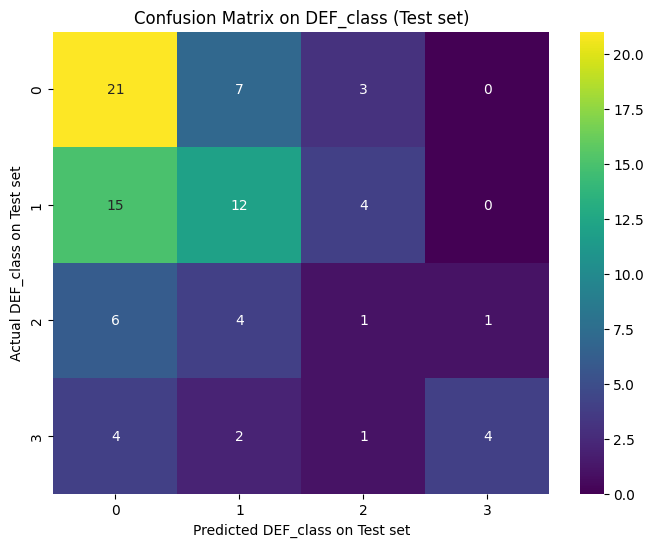

In [ ]:
#Confusion matrix on DEF_class (test set)

#Print classification report
print(classification_report(y_test1, test_predictions1))


cm_test1 = confusion_matrix(y_test1, test_predictions1)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test1, annot=True, cmap='viridis', fmt='g', cbar='False')
plt.xlabel("Predicted DEF_class on Test set")
plt.ylabel("Actual DEF_class on Test set")
plt.title("Confusion Matrix on DEF_class (Test set)")
plt.show()

              precision    recall  f1-score   support

           0       0.43      0.62      0.51        26
           1       0.25      0.06      0.10        17
           2       0.43      0.58      0.49        31
           3       1.00      0.18      0.31        11

    accuracy                           0.44        85
   macro avg       0.53      0.36      0.35        85
weighted avg       0.47      0.44      0.39        85



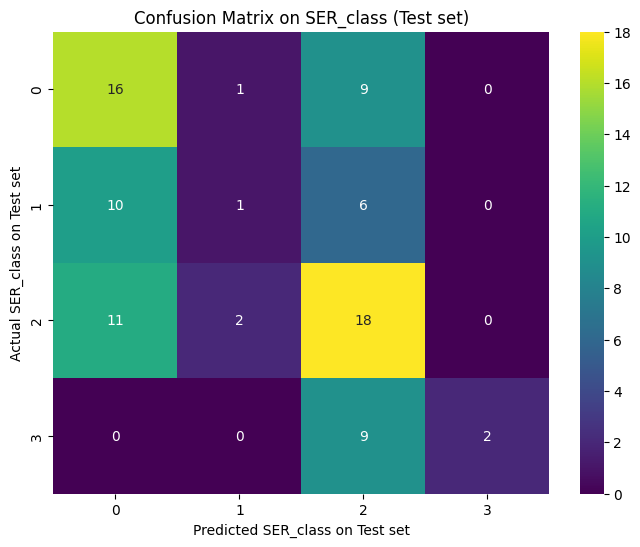

In [ ]:
#Confusion matrix on SER_class (test set)

#Print classification report
print(classification_report(y_test2, test_predictions2))


cm_test2 = confusion_matrix(y_test2, test_predictions2)

plt.figure(figsize=(8,6))
sns.heatmap(cm_test2, annot=True, cmap='viridis', fmt='g', cbar='False')
plt.xlabel("Predicted SER_class on Test set")
plt.ylabel("Actual SER_class on Test set")
plt.title("Confusion Matrix on SER_class (Test set)")
plt.show()

**STEP 10 - USER INTERFACE: CREATE NEW EXPERIMENTAL SCENARIOS**

In this section, the user is allowed to manually type input parameters in order to get an output prediction for a defined irradiation experiment.

In [ ]:
#Input dialog boxes
def get_input_features():
  features = []
  print("Please enter the values for the input features:")
  for name in feature_names_inbox:
    feature_value = float(input(f"{name}: "))
    features.append(feature_value)
  return features

#List of input features
feature_names_inbox = [
    "Atomic number Z of the metallic nanoparticle",
    "Core diameter of the nanoparticle (nm)",
    "Nanoparticle solution concentration (mmol/L)",
    "Incubation time (h)",
    "Cell line category (Non-cancerous = 0 ; Very radioresistant = 1 ; Radioresistant = 2 ; Mildly radiosensistive = 3 ; Radiosensitive = 4 ; Very radiosensitive = 5)",
    "Oxygenation conditions (Normoxic = 2 ; Hypoxic = 1 ; Anoxic = 0)",
    "Nature of ionizing ray (X-ray = 1 ; Gamma-ray = 2 ; Electron = 3 ; Proton = 4 ; Helium ion = 5 ; Carbon ion = 6)",
    "Energy of ionizing ray (keV)",
    "Linear Energy Transfer (keV/um)",
    "Alpha Control (Gy-1)",
    "Beta Control (Gy-2)"
    ]

input_features = get_input_features()
print("Input features:", input_features)

Please enter the values for the input features:
Atomic number Z of the metallic nanoparticle: 83
Core diameter of the nanoparticle (nm): 50
Nanoparticle solution concentration (mmol/L): 1
Incubation time (h): 24
Cell line category (Non-cancerous = 0 ; Very radioresistant = 1 ; Radioresistant = 2 ; Mildly radiosensistive = 3 ; Radiosensitive = 4 ; Very radiosensitive = 5): 5
Oxygenation conditions (Normoxic = 2 ; Hypoxic = 1 ; Anoxic = 0): 2
Nature of ionizing ray (X-ray = 1 ; Gamma-ray = 2 ; Electron = 3 ; Proton = 4 ; Helium ion = 5 ; Carbon ion = 6): 6
Energy of ionizing ray (keV): 3480000
Linear Energy Transfer (keV/um): 70
Alpha Control (Gy-1): 0.45
Beta Control (Gy-2): 0.08
Input features: [83.0, 50.0, 1.0, 24.0, 5.0, 2.0, 6.0, 3480000.0, 70.0, 0.45, 0.08]


In [ ]:
#Whole set data recuperation and standardization
mean = x_data.mean()
std = x_data.std()
x_data_standardized = (x_data - mean) / std

#Convert y_data into a Numpy array
y_data1 = np.ravel(y_data1)
y_data2 = np.ravel(y_data2)

display(x_data.describe().style.format("{0:.2f}").set_caption("x_data"))
display(x_data_standardized.describe().style.format("{0:.2f}").set_caption("x_data_standardized"))

#Standardization of user inputs
means = np.mean(x_data, axis=0)
stds = np.std(x_data, axis=0)

manually_standardized_input_features = [(x - mean) / std for x, mean, std in zip (input_features, means, stds)]
print("List of manually standardized input features:")
print(manually_standardized_input_features)

#Define ensemble final classifier for DEF_class prediction
class EnsembleFinalClassifier1:
  def __init__(self, models, weights):
    self.models = models
    self.weights = weights

  def fit(self, x_data_standardized, y_data1):
    for model in self.models:
      model.fit(x_data_standardized, y_data1)

  def predict(self, x_data_standardized):
    weighted_final_predictions1 = np.zeros((x_data.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_final_predictions1 += weight * model.predict_proba(x_data_standardized)
    return np.argmax(weighted_final_predictions1, axis=1)

  def predict_proba(self, x_data_standardized):
    weighted_final_predictions1 = np.zeros((x_data_standardized.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_final_predictions1 += weight * model.predict_proba(x_data_standardized)
    return weighted_final_predictions1 / np.sum(self.weights)

#Define and fit regression model
regression_model1 = EnsembleFinalClassifier1(models=[final_model1a, final_model1b], weights=optimized_weights1)
regression_model1.fit(x_data_standardized, y_data1)
# regression_model1.predict([manually_standardized_input_features])


#Define ensemble final classifier for SER_class prediction
class EnsembleFinalClassifier2:
  def __init__(self, models, weights):
    self.models = models
    self.weights = weights

  def fit(self, x_data_standardized, y_data2):
    for model in self.models:
      model.fit(x_data_standardized, y_data2)

  def predict(self, x_data_standardized):
    weighted_final_predictions2 = np.zeros((x_data.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_final_predictions2 += weight * model.predict_proba(x_data_standardized)
    return np.argmax(weighted_final_predictions2, axis=1)

  def predict_proba(self, x_data_standardized):
    weighted_final_predictions2 = np.zeros((x_data_standardized.shape[0], len(self.models[0].classes_)))
    for model, weight in zip (self.models, self.weights):
      weighted_final_predictions2 += weight * model.predict_proba(x_data_standardized)
    return weighted_final_predictions2 / np.sum(self.weights)

#Define and fit ensemble model
regression_model2 = EnsembleFinalClassifier2(models=[final_model2a, final_model2b], weights=optimized_weights2)
regression_model2.fit(x_data_standardized, y_data2)

,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl
count,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00
mean,66.22,26.76,3.85,17.88,2.46,1.93,1.85,289706.78,5.13,0.24,0.04
std,19.98,34.63,15.65,10.30,1.23,0.32,1.61,875302.13,16.55,0.24,0.03
min,22.00,1.20,0.00,0.00,0.00,0.00,1.00,8.05,0.00,-0.32,-0.02
25%,64.00,3.00,0.10,6.00,2.00,2.00,1.00,67.00,0.00,0.07,0.01
50%,78.00,12.70,0.48,24.00,2.00,2.00,1.00,662.00,0.00,0.17,0.03
75%,79.00,50.00,0.80,24.00,3.00,2.00,2.00,2000.00,0.00,0.37,0.05
max,83.00,200.00,100.00,72.00,5.00,2.00,6.00,3480000.00,110.00,1.54,0.20


,Np_type,Diam,Concentration,Incubation,Cell_type,Oxygenation,Ray_type,Energy,Let,Alpha_ctrl,Beta_ctrl
count,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00,424.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.21,-0.74,-0.25,-1.74,-2.00,-5.99,-0.52,-0.33,-0.31,-2.28,-1.90
25%,-0.11,-0.69,-0.24,-1.15,-0.38,0.20,-0.52,-0.33,-0.31,-0.69,-0.82
50%,0.59,-0.41,-0.22,0.59,-0.38,0.20,-0.52,-0.33,-0.31,-0.26,-0.15
75%,0.64,0.67,-0.19,0.59,0.43,0.20,0.09,-0.33,-0.31,0.55,0.50
max,0.84,5.00,6.14,5.25,2.06,0.20,2.57,3.64,6.34,5.34,5.39


List of manually standardized input features:
[0.8410492223214262, 0.6717821744066714, -0.18227304917912635, 0.5942387056414095, 2.0580769412508806, 0.20464687117164046, 2.5750265239611947, 3.6490965829752215, 3.9238273212243557, 0.8795660734151172, 1.409508976722376]


In [ ]:
#Make a prediction
predicted_def = regression_model1.predict([manually_standardized_input_features])
predicted_ser = regression_model2.predict([manually_standardized_input_features])

#Inputs recuperation (Alpha Control and Beta Control)
Alpha_input = input_features[9]
Beta_input = input_features[10]

#Outputs recuperation (Alpha NP and Beta NP)
def_output = predicted_def[0]
ser_output = predicted_ser[0]

#Extrapolated output quantities
Sref = 0.1
Dref = 2  #[Gy]

print("Alpha Control =", "{:.2f}".format(Alpha_input), "Gy-1")
print("Beta Control =", "{:.2f}".format(Beta_input), "Gy-2")
print("DEF = Class", "{:.0f}".format(def_output))
print("SER = Class", "{:.0f}".format(ser_output))
print("")
print("")

Alpha Control = 0.45 Gy-1
Beta Control = 0.08 Gy-2
DEF = Class 1
SER = Class 3




/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Establish Enhancement index

#Define DEF impact coefficient
def_impact = 0.5    #Number between 0 and 1 (0 = DEF value has no importance; 1 = SER value has no importance)

enhancement_index = (def_impact * (def_output - ser_output) + ser_output) / 3
print("Enhancement index =", "{:.2f}".format(enhancement_index))

Enhancement index = 0.67
